
Univariate Regression


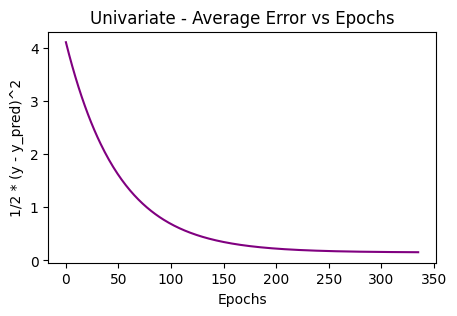

Training Data -> RMSE: 0.5560, %RMSE: 20.31%
Test Data     -> RMSE: 0.5634, %RMSE: 20.69%


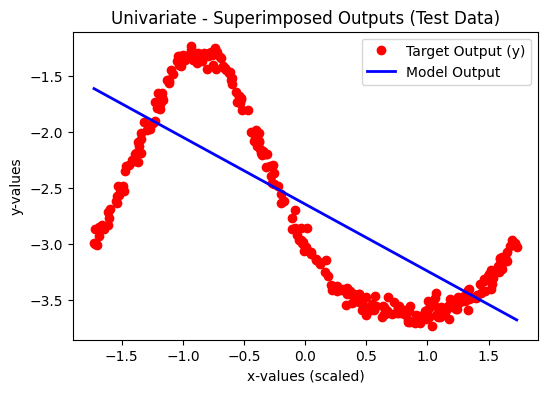

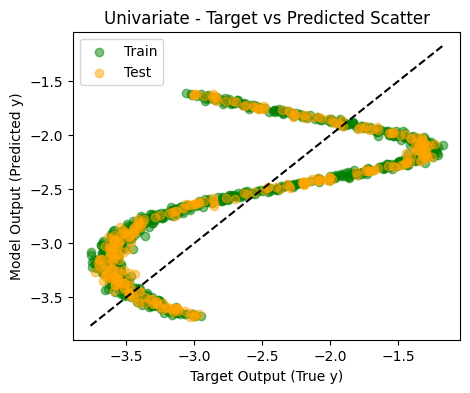


Bivariate Regression


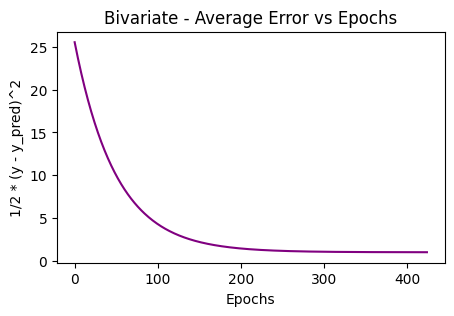

Training Data -> RMSE: 1.4231, %RMSE: 20.36%
Test Data     -> RMSE: 1.4288, %RMSE: 20.52%


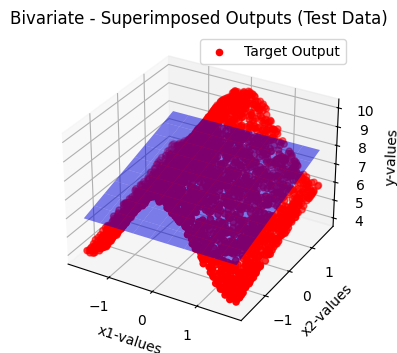

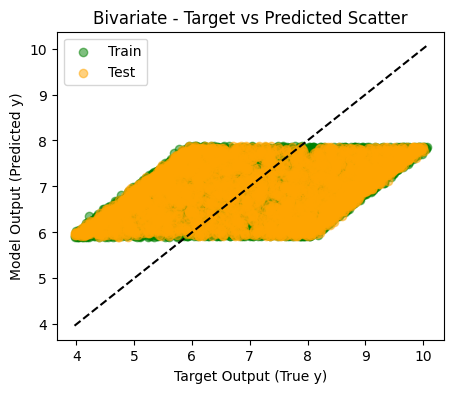

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LINEAR PERCEPTRON FOR REGRESSION 
# ==========================================
class LinearPerceptron:
    # ADDED 'tol' for convergence criterion
    def __init__(self, input_dim, lr=0.001, epochs=1000, tol=1e-4):
        self.weights = np.random.randn(input_dim + 1) * 0.01
        self.lr = lr
        self.epochs = epochs
        self.tol = tol
        self.loss_history = []

    def train(self, X, y):
        n_samples = X.shape[0]
        # Bias Trick: Add a column of 1s to X
        X_aug = np.c_[np.ones(n_samples), X]
        
        prev_loss = float('inf')
        
        for epoch in range(self.epochs):
            # Linear activation: y_pred = z
            preds = np.dot(X_aug, self.weights)
            
            # Error = (y_actual - y_pred)
            error = y - preds
            
            # Error formula taught: 1/2 * error^2
            current_loss = np.mean(0.5 * error**2)
            self.loss_history.append(current_loss)
            
            # --- CONVERGENCE CRITERION ---
            if abs(prev_loss - current_loss) < self.tol:
                # print(f"Regression converged at epoch {epoch}")
                break
            prev_loss = current_loss
            
            # Gradient descent rule derived directly from 1/2 * (y - y_pred)^2
            dw = np.dot(X_aug.T, -error) / n_samples
            
            # Update weights purely based on error
            self.weights -= self.lr * dw

    def predict(self, X):
        X_aug = np.c_[np.ones(X.shape[0]), X]
        return np.dot(X_aug, self.weights)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def preprocess_regression(filepath):
    data = pd.read_csv(filepath, header=None).values
    X = data[:, :-1]
    y = data[:, -1]
    
    # Feature Scaling
    X_mean, X_std = np.mean(X, axis=0), np.std(X, axis=0)
    X_scaled = (X - X_mean) / (X_std + 1e-8)
    
    n_samples = len(X)
    split_idx = int(n_samples * 0.7)
    
    X_train, y_train = X_scaled[:split_idx], y[:split_idx]
    X_test, y_test = X_scaled[split_idx:], y[split_idx:]
    
    return X_train, y_train, X_test, y_test, X, y, X_mean, X_std

def calculate_rmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mean_y = np.mean(y_true) if np.mean(y_true) != 0 else 1e-8
    pct_rmse = (rmse / np.abs(mean_y)) * 100
    return rmse, pct_rmse

# ==========================================
# 3. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    
    # Using your updated paths
    datasets = {
        "Univariate": 'Regression/UnivariateData/24.csv',
        "Bivariate": 'Regression/BivariateData/24.csv'
    }
    
    for name, path in datasets.items():
        print(f"\n" + "="*40 + f"\n{name} Regression\n" + "="*40)
        
        X_tr, y_tr, X_te, y_te, X_raw, y_raw, X_m, X_s = preprocess_regression(path)
        
        # Added tol=1e-4 here
        model = LinearPerceptron(input_dim=X_tr.shape[1], lr=0.01, epochs=1000, tol=1e-4)
        model.train(X_tr, y_tr)
        
        plt.figure(figsize=(5, 3))
        plt.plot(model.loss_history, color='purple')
        plt.title(f"{name} - Average Error vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("1/2 * (y - y_pred)^2")
        plt.show()
        
        train_preds = model.predict(X_tr)
        test_preds = model.predict(X_te)
        
        tr_rmse, tr_p_rmse = calculate_rmse(y_tr, train_preds)
        te_rmse, te_p_rmse = calculate_rmse(y_te, test_preds)
        print(f"Training Data -> RMSE: {tr_rmse:.4f}, %RMSE: {tr_p_rmse:.2f}%")
        print(f"Test Data     -> RMSE: {te_rmse:.4f}, %RMSE: {te_p_rmse:.2f}%")
        
        plt.figure(figsize=(6, 4))
        if name == "Univariate":
            sort_idx = np.argsort(X_te[:, 0])
            plt.plot(X_te[sort_idx, 0], y_te[sort_idx], 'ro', label='Target Output (y)')
            plt.plot(X_te[sort_idx, 0], test_preds[sort_idx], 'b-', label='Model Output', linewidth=2)
            plt.xlabel('x-values (scaled)')
            plt.ylabel('y-values')
        else:
            ax = plt.axes(projection='3d')
            ax.scatter(X_te[:, 0], X_te[:, 1], y_te, c='r', label='Target Output')
            x1_grid, x2_grid = np.meshgrid(np.linspace(X_te[:,0].min(), X_te[:,0].max(), 10),
                                           np.linspace(X_te[:,1].min(), X_te[:,1].max(), 10))
            z_grid = model.predict(np.c_[x1_grid.ravel(), x2_grid.ravel()]).reshape(10, 10)
            ax.plot_surface(x1_grid, x2_grid, z_grid, alpha=0.5, color='blue')
            ax.set_xlabel('x1-values')
            ax.set_ylabel('x2-values')
            ax.set_zlabel('y-values')
            
        plt.title(f"{name} - Superimposed Outputs (Test Data)")
        plt.legend()
        plt.show()

        plt.figure(figsize=(5, 4))
        plt.scatter(y_tr, train_preds, c='green', alpha=0.5, label='Train')
        plt.scatter(y_te, test_preds, c='orange', alpha=0.5, label='Test')
        plt.plot([min(y_raw), max(y_raw)], [min(y_raw), max(y_raw)], 'k--')
        plt.xlabel('Target Output (True y)')
        plt.ylabel('Model Output (Predicted y)')
        plt.title(f"{name} - Target vs Predicted Scatter")
        plt.legend()
        plt.show()